In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

### Load pseudobulk and cell prop data

In [4]:
# # Load pseudobulk
# pseudo_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudo_bulk/pseudo_bulk_counts_id.csv", index_col=0)
# cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudo_bulk/pseudo_bulk_cell_type_proportions.csv", index_col=0)

### Load pseudobulk (HECA)

In [5]:
# # Heca (sn)
# pseudo_bulk = pd.read_csv ("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/czi_sub_heca/sn_pseudobulk_id.csv", index_col=0)
# cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/czi_sub_heca/sn_proportions.csv", index_col=0)

In [6]:
# Heca (sc)
pseudo_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/czi_sub_heca/pseudobulk_id.csv", index_col=0)
cell_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/czi_sub_heca/proportions.csv", index_col=0)

### Load reference data

In [7]:
# Path to single-cell RNAseq data 
path_ref = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/single_cell_refs/CZI04N_post_menopausal_sequence_duplicates.h5ad"
#path_ref = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/single_cell_refs/CZI041N_pre_menopausal.h5ad"

In [8]:
adata_ref = sc.read_h5ad(path_ref)

adata_ref.var.index = adata_ref.var["ensembl_id"]
adata_ref = adata_ref[:, adata_ref.var.index.notnull()]

In [9]:
adata_ref = adata_ref[:, adata_ref.var.index != "NA"]

In [10]:
adata_ref.obs["heca_lineage"].value_counts()

heca_lineage
Epithelial     5845
Endothelial    2037
Mesenchymal    1906
Name: count, dtype: int64

In [11]:
adata_ref.obs["id"].value_counts()

id
B4P4-CZI04N    6042
B4P1-CZI04N    3746
Name: count, dtype: int64

In [12]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata_ref,
                                  sample_col = "id", # sample id column
                                  cell_type_col = "heca_lineage",
                                  groupby = "heca_lineage",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T
sig_mat = sig_mat.loc[:, sig_mat.columns != "NA"]

In [13]:
sig_mat.columns.name = None
sig_mat.index.name = None

In [14]:
sig_mat.head()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
Endothelial,0.0,0.0,0.0,0.007855,0.000000,0.000000,0.008346,0.000491,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.002946,0.001964
Epithelial,0.0,0.0,0.0,0.009923,0.000342,0.000171,0.048246,0.003080,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000171,0.000000,0.000855,0.000171
Mesenchymal,0.0,0.0,0.0,0.003673,0.000000,0.000000,0.015215,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000525,0.000000,0.000000


### Extract Embeddings 

In [15]:
from embeddings import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [16]:
from deconvolution import *

In [17]:
from evaluation import *

In [28]:
# ctheodoris/Geneformer
model_path = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi/260806_geneformer_cellClassifier_gf_finetune/ksplit1/"
model_path_2 = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/260806_geneformer_cellClassifier_gf_finetune/ksplit1/"

sig_mat_gf_embed = extract_embs(
    bulk_df = sig_mat,
    mode = "geneformer", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.55s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, 
    mode = "geneformer",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "ctheodoris/Geneformer",
    layer_to_quant = 18,
    delete_temp_files = True
)

Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.71s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/8 [00:00<?, ?it/s]

In [34]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, 
                            signature_df = sig_mat_gf_embed.T, 
                            solver="nnls",
                            normalize = True)

In [35]:
cell_prop_pred.head()

,Endothelial,Epithelial,Mesenchymal
Epithelial_PB1,0.076658,0.923342,0.0
Mesenchymal_PB2,0.052383,0.947617,0.0
Epithelial_PB3,0.054258,0.945742,0.0
Epithelial_PB4,0.025716,0.974284,0.0
Endothelial_PB5,0.322137,0.677863,0.0


In [36]:
cell_prop.head()

,Epithelial,Endothelial,Mesenchymal
Epithelial_PB1,0.570000,0.186667,0.243333
Mesenchymal_PB2,0.638333,0.176667,0.185000
Epithelial_PB3,0.683333,0.148333,0.168333
Epithelial_PB4,0.710000,0.140000,0.150000
Endothelial_PB5,0.478333,0.383333,0.138333


In [37]:
compute_correlation(true_df=cell_prop, 
                    pred_df=cell_prop_pred, 
                    return_per_celltype=True)

{'overall': 0.6771428159198967,
 'per_celltype': Epithelial     0.866007
 Endothelial    0.924659
 Mesenchymal    0.767562
 Name: correlation, dtype: float64}

In [38]:
#cell_prop_pred.to_csv("../results/czi_pb/Heca_sc_zersoshot_estimated_proportions.csv")

### Fine-tuned 

In [24]:
from models import *

geneformer successfully imported.
Cell2Sentence is not installed. Skipping related functions.


In [25]:
adata_ref = load_and_prep_data(adata= adata_ref, cell_type_col= "heca_lineage", mode="geneformer")

In [26]:
#"/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi/czi_data_for_finetuning.h5ad"

In [27]:
adata_ref.write("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/czi_data_for_finetuning.h5ad")

In [28]:
gf_finetuned_metrics = train_geneformer_cell_classifier(adata_ref,
                                                        output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/",
                                                        state_key = "heca_lineage",
                                                        cell_types = None, # list of cell types to finetune 
                                                        tokenize = True,
                                                        tokenized_data_dir = None, # path to store tokenized data
                                                        token_output_prefix = "tokenized", #  prefix for tokenized data
                                                        undersample = True, # should data be undersampled 
                                                        n_per_class = 200, # if undersampling, max # cell per cell type
                                                        n_test_per_class = 80, # max number of  cells per cell type in test dataset (holdout dataset)
                                                        eval_fraction = 0.2, # Fraction of train data to be used for eval
                                                        model_directory = "ctheodoris/Geneformer", # Model directory
                                                        freeze_layers = 2, # freeze layer
                                                        num_crossval_splits = 1, # single train/eval split, 5 5-fold cross validation
                                                        forward_batch_size = 10, # batch size 
                                                        nproc = 8,
                                                        max_ncells = None, # Max number of cells for fine-tuning 
                                                        training_args = {"num_train_epochs": 3}, # training arguments 
                                                        output_prefix = "gf_finetune", # output directory 
                                                        metrics_output_dir = None, # if seperate output directory is required 
                                                       )

2026-08-06 21:54:48,415 [INFO] Training arguments: {'num_train_epochs': 3, 'learning_rate': 5e-05, 'lr_scheduler_type': 'cosine', 'warmup_steps': 190, 'weight_decay': 0.1, 'per_device_train_batch_size': 4, 'gradient_accumulation_steps': 8, 'seed': 42, 'fp16': True}
2026-08-06 21:54:48,415 [INFO] Tokenizing data → /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/tokenized


Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/czi_data_for_finetuning.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:08<00:00,  1.00s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/czi_data_for_finetuning.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


2026-08-06 21:55:06,420 [INFO] Tokenization complete: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/tokenized/tokenized.dataset
2026-08-06 21:55:06,423 [INFO] Undersampling: max 200 cells per class
2026-08-06 21:55:06,435 [INFO] Split sizes — train pool: 600 | test: 240
2026-08-06 21:55:06,437 [INFO] Train: 480 | Eval: 120 | Test: 240
2026-08-06 21:55:06,441 [INFO] Preparing data splits…
2026-08-06 21:55:08,415 [INFO] Starting training…


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.081600,0.996379,0.800000,0.792319
2,0.979800,0.603788,0.958333,0.957980
3,0.639200,0.099530,0.958333,0.957790


  0%|          | 0/12 [00:00<?, ?it/s]

2026-08-06 21:57:21,621 [INFO] Evaluating on test set…


  0%|          | 0/24 [00:00<?, ?it/s]

2026-08-06 21:57:43,599 [INFO] Metrics saved to /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/metrics/gf_finetune_metrics.pkl
2026-08-06 21:57:43,599 [INFO] Done.


In [29]:
# Get confusion matrix on test data 
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

In [30]:
# Empty data frame to store fine tuning results 
metrics = pd.DataFrame(index=conf_matrix.index, columns=["Precision", "Recall", "F1", "Accuracy"])

for cls in conf_matrix.columns:
    tp = conf_matrix.loc[cls, cls]  # TP
    fp = conf_matrix[cls].sum() - tp  # FP
    fn = conf_matrix.loc[cls].sum() - tp  # FN
    tn = conf_matrix.values.sum() - (tp + fp + fn)  # TN

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / conf_matrix.values.sum()

    metrics.loc[cls] = [precision, recall, f1, accuracy]

# Convert all to float and round for readability
metrics = metrics.astype(float).round(3)

# Sort by F1 score (descending order)
metrics = metrics.sort_values(by="F1", ascending=False)

print(metrics)

             Precision  Recall     F1  Accuracy
Epithelial       1.000   1.000  1.000     1.000
Endothelial      1.000   0.988  0.994     0.996
Mesenchymal      0.988   1.000  0.994     0.996


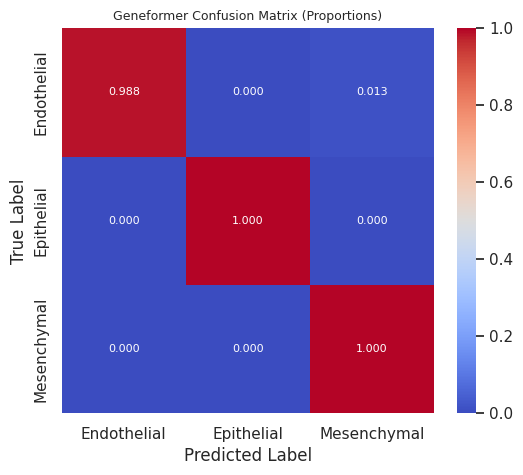

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                
    fmt=".3f",                 
    cmap="coolwarm",          
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

<b> Finetuned model </b> should now be available through this path `/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi/260806_geneformer_cellClassifier_gf_finetune/ksplit1/`

<b> Finetuned model </b> should now be available through this path `/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/czi_CZI041N/260806_geneformer_cellClassifier_gf_finetune/ksplit1/`